In [1]:
import os
import json
import gzip
import pandas as pd
import numpy as np

import scipy.sparse as spsparse
import scipy.stats as spstats

from statsmodels.stats.multitest import multipletests as holm
import statsmodels.api as sm

import matplotlib.pylab as plt
import seaborn as sns

import matplotlib.gridspec as gridspec
import matplotlib.transforms as transforms



In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
colours=['#8D95A0','#2171b5','#DA6437']

# Figures

In [6]:
dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')


conditions_plot = [
(dfself_vars['significant'] == True) & (dfself_vars['zscore'] < 0),
(dfself_vars['significant'] == True) & (dfself_vars['zscore'] > 0),
(dfself_vars['significant'] == False)]

choices_plot = [-1, dfself_vars['logzscore'], 0]

dfself_vars['self_for_plot'] = np.select(conditions_plot, choices_plot, default=np.nan)


# Figure S1: Temporal distribution of national citation self-preference across countries (1990–2019).

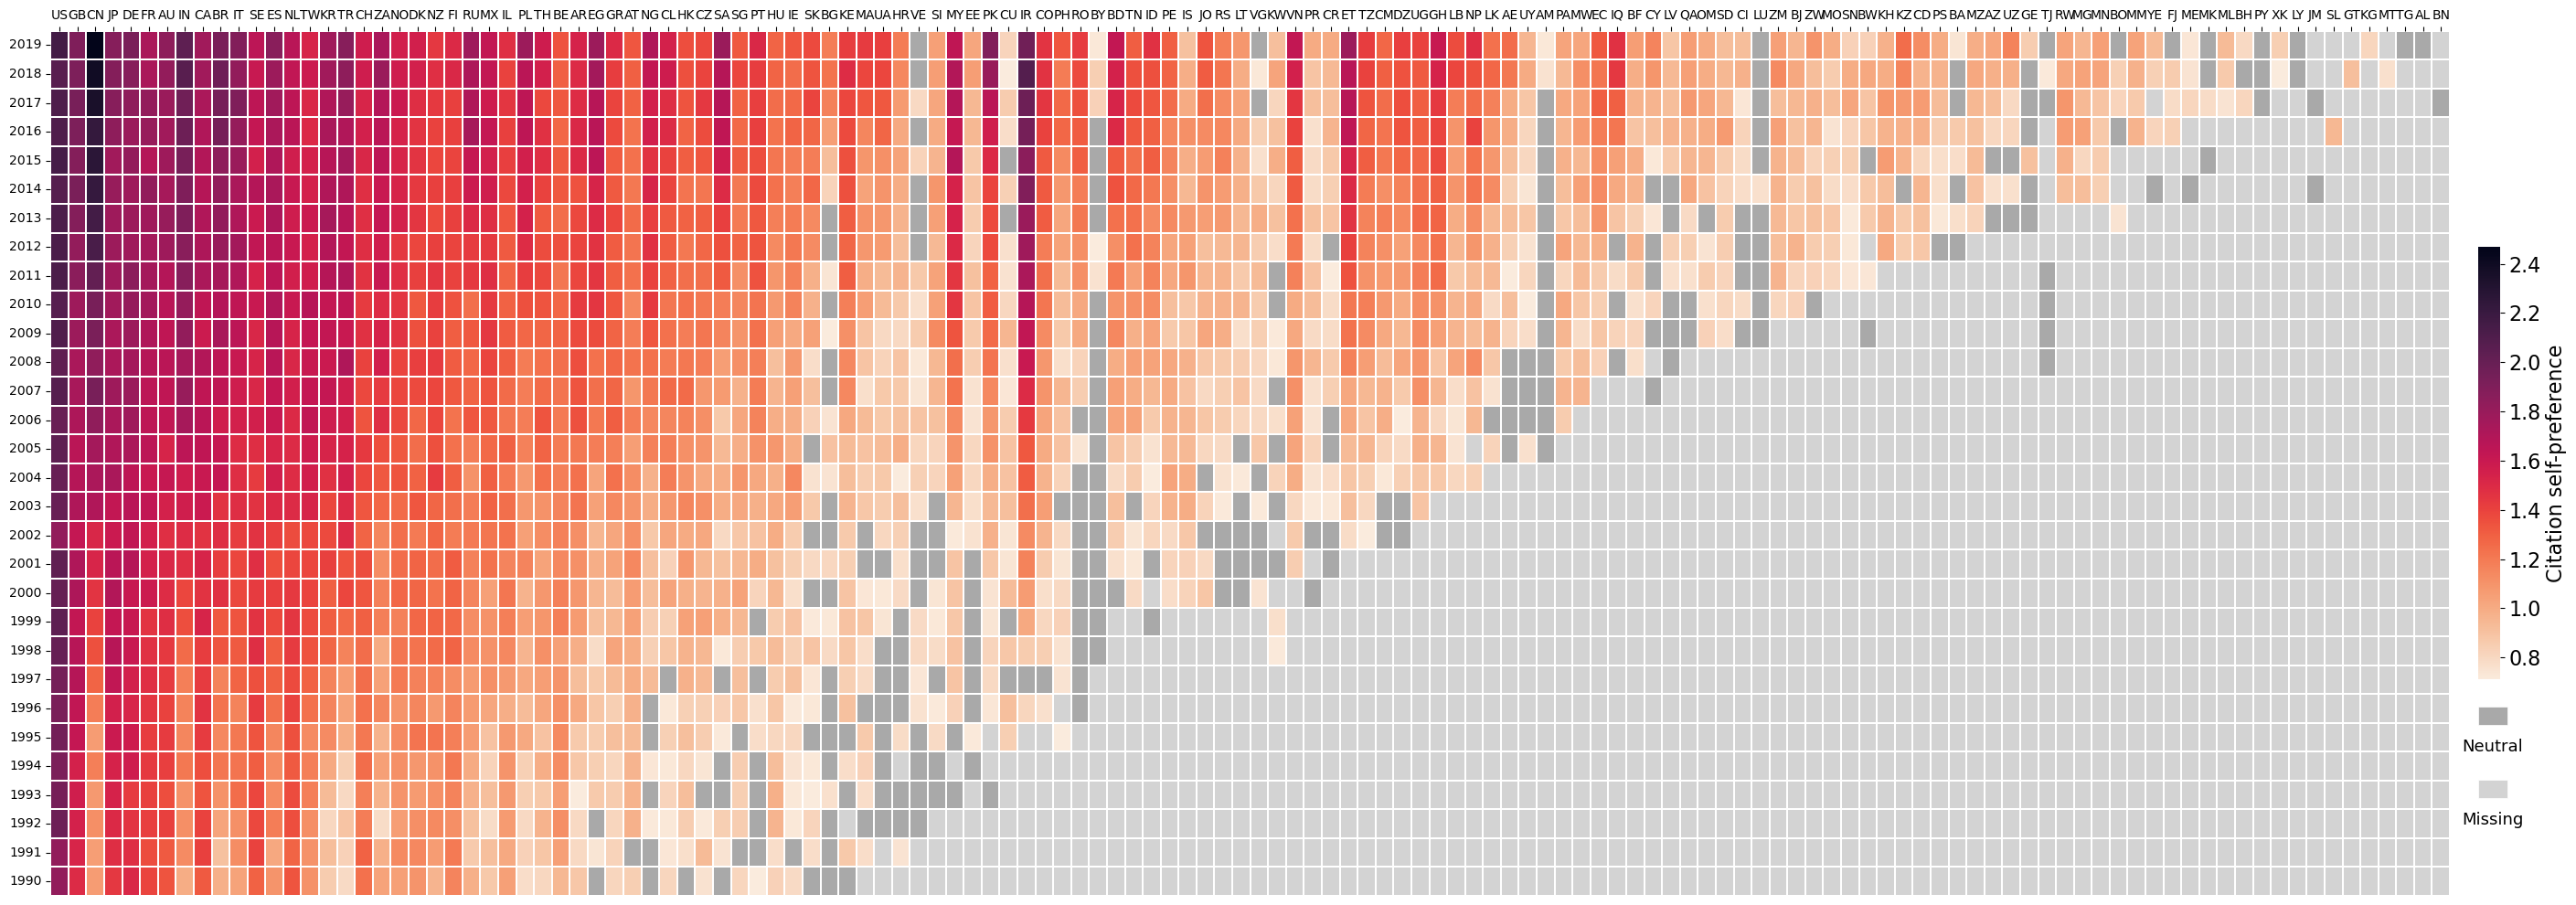

In [7]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle

filename_suffix='noselfauthor_bootstrap'


dfself_vars['Year'] = dfself_vars['Year'].astype(int)

heatmap_data = dfself_vars.pivot(index='Year', columns='Country', values='self_for_plot')

heatmap_data = heatmap_data.sort_index(ascending=False)

non_missing_counts = heatmap_data.notna().sum(axis=0)
mean_logzscore = dfself_vars.groupby('Country')['logzscore'].mean()
sort_order = (
    pd.DataFrame({
        'non_missing': non_missing_counts,
        'mean_logzscore': mean_logzscore
    })
    .sort_values(by=['non_missing', 'mean_logzscore'], ascending=[False, False])
    .index
)
heatmap_data = heatmap_data[sort_order]

mask_nan = heatmap_data.isna()
mask_zero = (heatmap_data == 0)

data_nonzero = heatmap_data.mask(mask_zero | mask_nan)

fig, ax = plt.subplots(figsize=(32, 10))

# 1) Nonzero layer with rocket_r colormap
cmap_main = sns.color_palette("rocket_r", as_cmap=True)
norm = plt.Normalize(vmin=np.nanmin(data_nonzero), vmax=np.nanmax(data_nonzero))
sns.heatmap(data_nonzero, cmap=cmap_main, norm=norm,
            cbar=True, linewidths=0.05, linecolor='w',
            cbar_kws={'label': 'Citation self-preference', 'shrink': 0.5, 'pad': 0.01},
            ax=ax)

# 2) Zero layer (darkgray)
zero_data = heatmap_data.copy()
zero_data = zero_data.where(~mask_zero, 1)
zero_data = zero_data.where(mask_zero, np.nan)
sns.heatmap(zero_data, cmap=ListedColormap(['darkgray']),
            cbar=False, linewidths=0.05, linecolor='w', ax=ax,
            vmin=0.5, vmax=1.5)

# 3) NaN layer (lightgray)
nan_data = heatmap_data.copy()
nan_data = nan_data.where(~mask_nan, 1)
nan_data = nan_data.where(mask_nan, np.nan)
sns.heatmap(nan_data, cmap=ListedColormap(['lightgray']),
            cbar=False, linewidths=0.05, linecolor='w', ax=ax,
            vmin=0.5, vmax=1.5)

cbar = ax.collections[0].colorbar
cbar_ax = cbar.ax
cbar_pos = cbar_ax.get_position()
cbar.ax.tick_params(labelsize=16) 
cbar.set_label('Citation self-preference', fontsize=16)

legend_height = 0.02
legend_width = 0.01
spacing = 0.02

dark_x = cbar_pos.x0 + 0.065
dark_y = cbar_pos.y0 - 4*legend_height - spacing

light_x = cbar_pos.x0 + 0.065
light_y = cbar_pos.y0 - 8*legend_height - spacing

dark_rect = Rectangle((dark_x, dark_y), legend_width, legend_height, 
                     facecolor='darkgray', edgecolor='w', linewidth=0.5,
                     transform=fig.transFigure, clip_on=False)
light_rect = Rectangle((light_x, light_y), legend_width, legend_height, 
                      facecolor='lightgray', edgecolor='w', linewidth=0.5,
                      transform=fig.transFigure, clip_on=False)

fig.patches.extend([dark_rect, light_rect])

fig.text(dark_x + legend_width/2, dark_y - 0.015, 'Neutral', 
         ha='center', va='top', fontsize=13, transform=fig.transFigure)
fig.text(light_x + legend_width/2, light_y - 0.015, 'Missing', 
         ha='center', va='top', fontsize=13, transform=fig.transFigure)

ax.xaxis.set_ticks_position('top')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()

plt.savefig(f"FigureSelfCitation/NewData/SI_self_heatmap_{filename_suffix}.pdf", bbox_inches='tight')

# Figure S2: Temporal evolution of citation self-preference across major scientific nations (1990-2019).

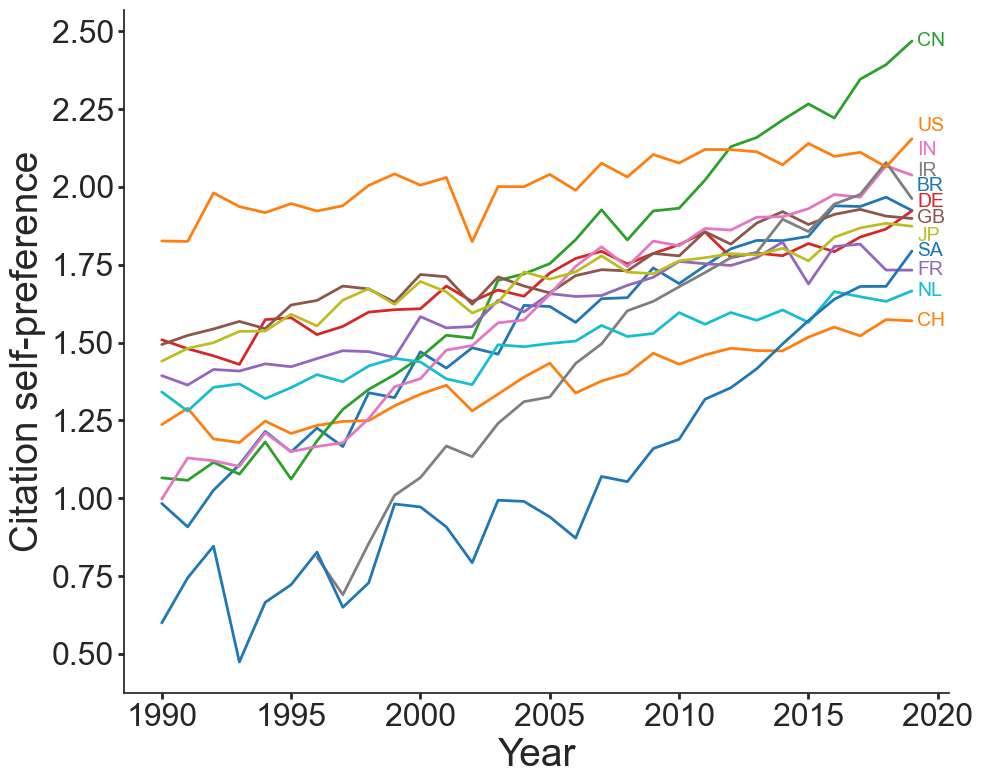

In [26]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   

filename_suffix='noselfauthor_bootstrap'

countries = ['US','GB', 'DE', 'FR', 'JP', 'NL', 'CH', 'CN', 'IN', 'BR', 'SA','IR']
plot_data = dfself_vars[dfself_vars['Country'].isin(countries)]

plt.figure(figsize=(10, 8))
ax = sns.lineplot(data=plot_data, x='Year', y='logzscore', hue='Country', lw=2, palette='tab10')

handles, labels = ax.get_legend_handles_labels()
color_map = dict(zip(labels, [h.get_color() for h in handles]))

for country in countries:
    country_data = plot_data[plot_data['Country'] == country]
    last_point = country_data[country_data['Year'] == country_data['Year'].max()]
    if not last_point.empty:
        x = last_point['Year'].values[0]
        y = last_point['logzscore'].values[0]
        if country in ['US',]:
            ax.text(x + 0.2, y+0.04, country, color=color_map[country], fontsize=14, va='center')
        elif country in ['IN','BR']:
            ax.text(x + 0.2, y+0.08, country, color=color_map[country], fontsize=14, va='center')
        elif country in ['IR']:
            ax.text(x + 0.2, y+0.09, country, color=color_map[country], fontsize=14, va='center')
        elif country in ['DE']:
            ax.text(x + 0.2, y+0.03, country, color=color_map[country], fontsize=14, va='center')
        elif country in ['JP']:
            ax.text(x + 0.2, y-0.03, country, color=color_map[country], fontsize=14, va='center')
   
        else:
            ax.text(x + 0.2, y, country, color=color_map[country], fontsize=14, va='center')

            

ax.legend_.remove()

ax.set_xlabel('Year', fontsize=28)
ax.set_ylabel('Citation self-preference', fontsize=28)
ax.tick_params(labelsize=23, direction='out', length=4, width=2) 


plt.tight_layout()
plt.savefig(f"FigureSelfCitation/NewData/SI_zscore_temporal_{filename_suffix}.pdf", bbox_inches='tight')

# Figure S3: Distribution of main variables across all country-year observations (1990-2019). 

In [27]:
custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)
   

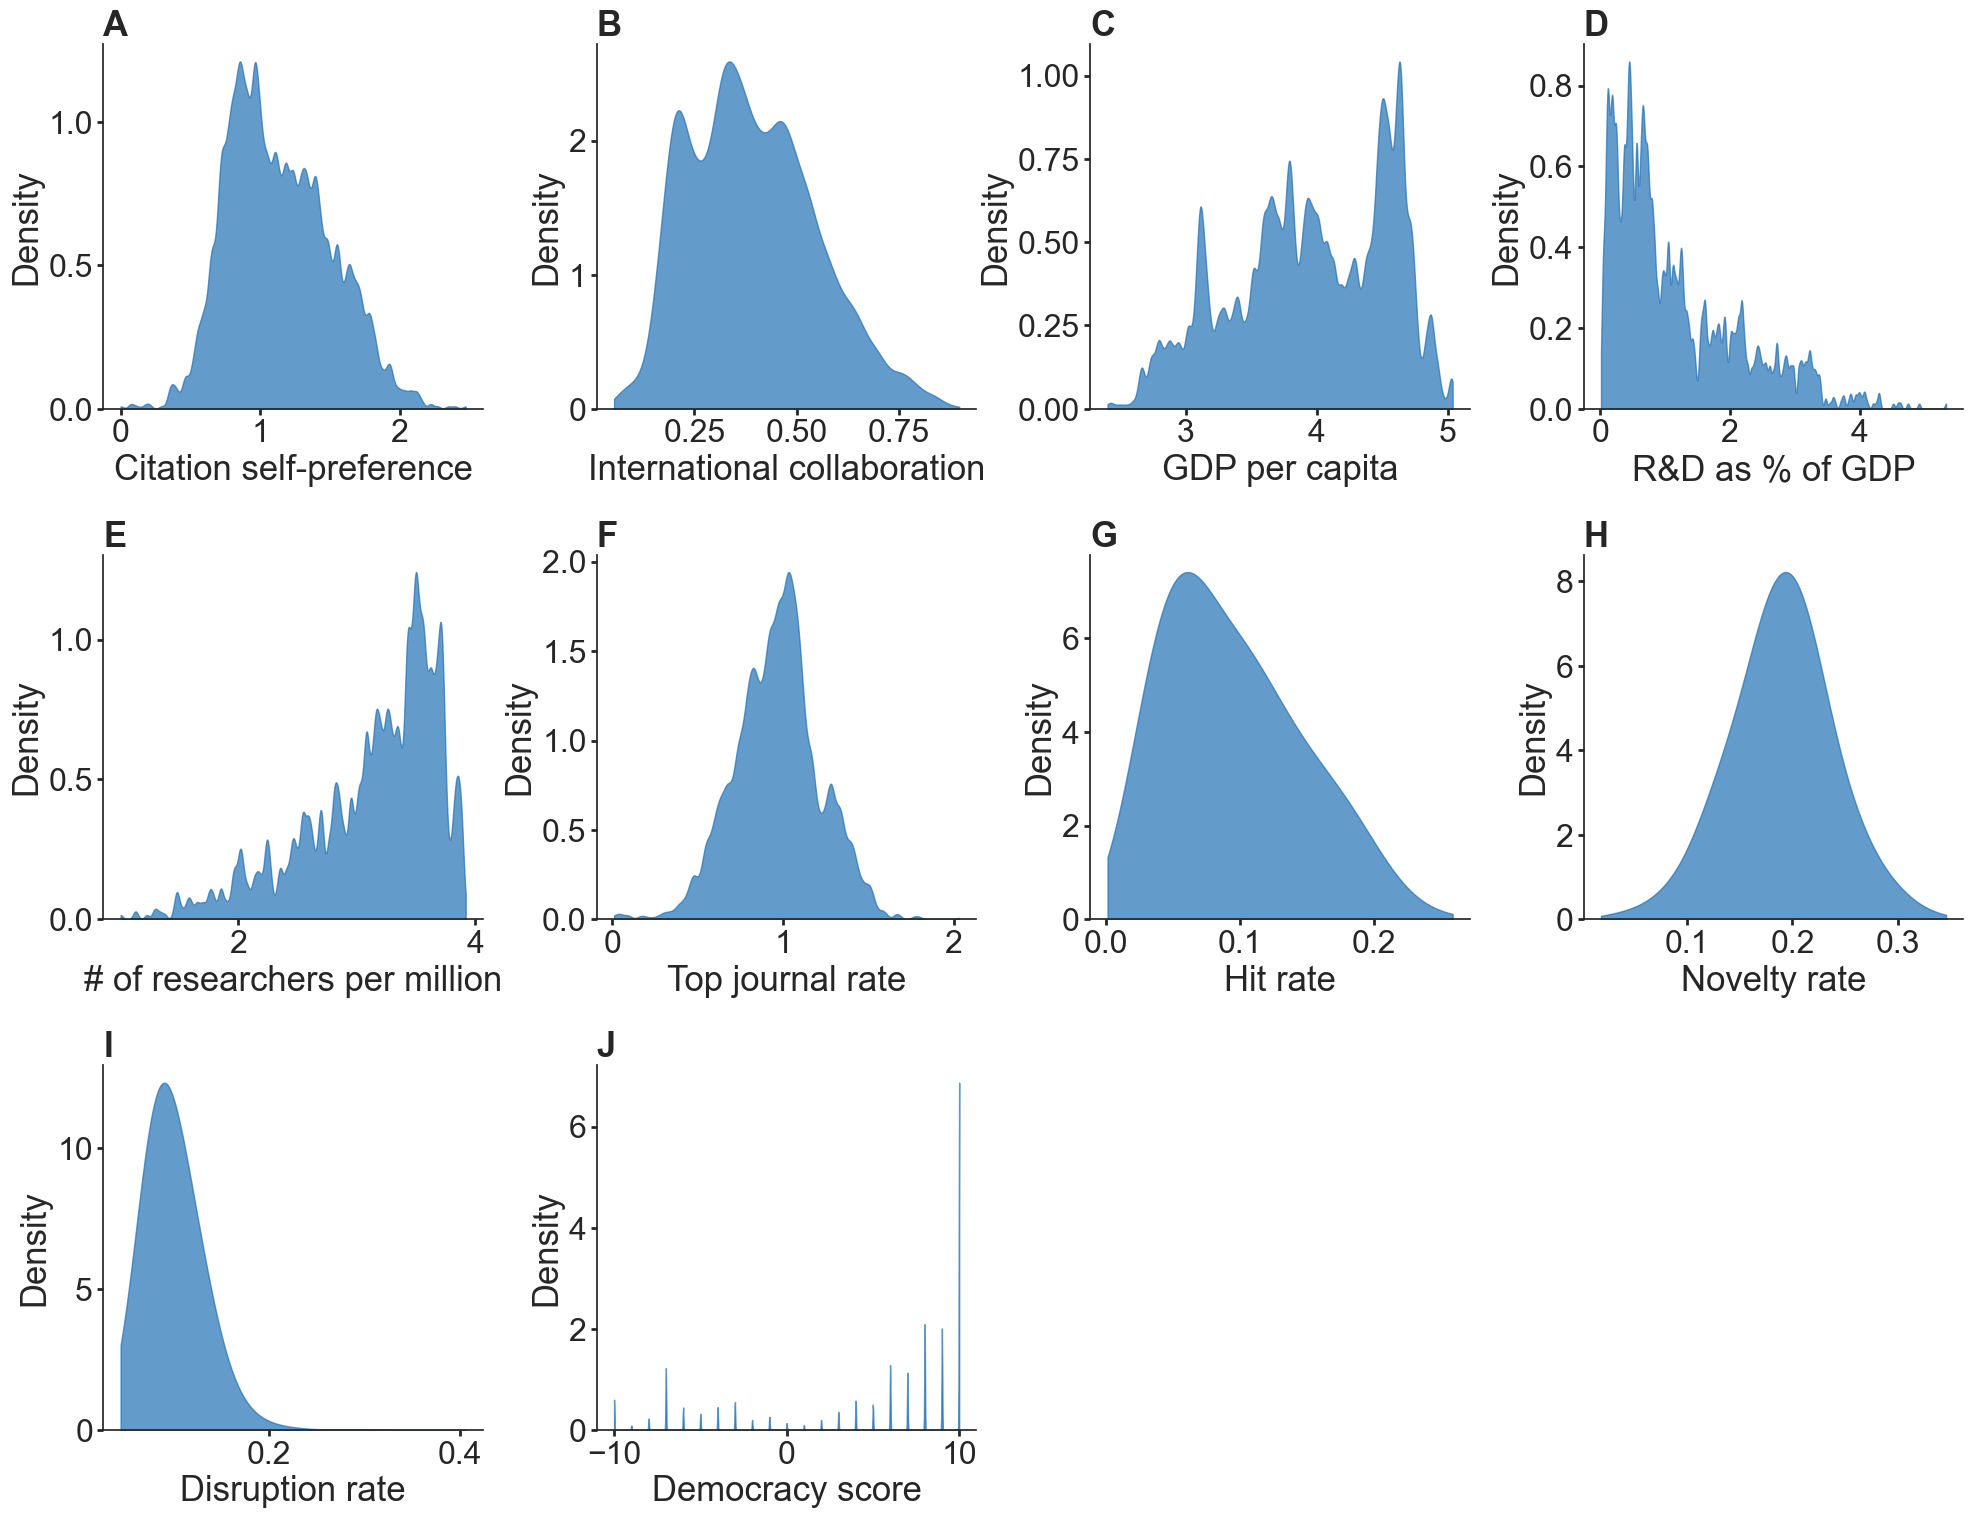

In [32]:
from sklearn.neighbors import KernelDensity

def make_kde(x, x_d=np.linspace(0, 1, 1000), bandwidth=0.01, color='k', alpha=0.5, ax=None):
    kde = KernelDensity(bandwidth=bandwidth, kernel='gaussian')
    kde.fit(x[:, None])

    # score_samples returns the log of the probability density
    logprob = kde.score_samples(x_d[:, None])

    ax.fill_between(x_d, np.exp(logprob), alpha=alpha, color=color)
    return ax

layout = [
    ["A", "B",'C','D'],
    ['E','F','G','H'],
    ['I','J','.','.']
    
]

fig, axes = plt.subplot_mosaic(layout, figsize=(24,18), 
                                  gridspec_kw={'height_ratios': [1,1,1],  "hspace": 0.4, "wspace": 0.3},
                                 constrained_layout=True, )
for label, ax in axes.items():
    ax.set_title(label, loc='left', fontweight='bold', fontsize=25, )  # Title at the upper left corner
    ax.title.set_x(-10)


filename_suffix='noselfauthor_bootstrap'

plot_data2=dfself_vars.copy()


arr = np.array(plot_data2['logzscore'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(np.array(plot_data2['logzscore']), x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['A'])


axes['A'].set_ylabel('Density', fontsize=25)
axes['A'].set_xlabel('Citation self-preference', fontsize=25)
axes['A'].set_ylim(bottom=0)
#axes['A'].axvline(x=0, color=colours[2], linestyle='--', linewidth=2.5)
axes['A'].tick_params(labelsize=23, direction='out', length=4, width=2) 


arr = np.array(plot_data2['FracInternationalAuthors'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['B'])


axes['B'].set_ylabel('Density', fontsize=25)
axes['B'].set_xlabel('International collaboration', fontsize=25)
axes['B'].set_ylim(bottom=0)
axes['B'].tick_params(labelsize=23, direction='out', length=4, width=2) 

arr = np.array(plot_data2['GDP_PCAP'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['C'])


axes['C'].set_ylabel('Density', fontsize=25)
axes['C'].set_xlabel('GDP per capita', fontsize=25)
axes['C'].set_ylim(bottom=0)
#axes['C'].axvline(x=0, color=colours[2], linestyle='--', linewidth=2.5)
axes['C'].tick_params(labelsize=23, direction='out', length=4, width=2) 


arr = np.array(plot_data2['RND_per'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['D'])


axes['D'].set_ylabel('Density', fontsize=25)
axes['D'].set_xlabel('R&D as % of GDP', fontsize=25)
axes['D'].set_ylim(bottom=0)
axes['D'].tick_params(labelsize=23, direction='out', length=4, width=2) 



arr = np.array(plot_data2['NResearchers'])
arr_no_nan = np.log10(arr[~np.isnan(arr)])

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['E'])

axes['E'].set_ylabel('Density', fontsize=25)
axes['E'].set_xlabel('# of researchers per million', fontsize=25)
axes['E'].set_ylim(bottom=0)
axes['E'].tick_params(labelsize=23, direction='out', length=4, width=2) 


arr = np.array(plot_data2['normalized_frac_top'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['F'])

axes['F'].set_ylabel('Density', fontsize=25)
axes['F'].set_xlabel('Top journal rate', fontsize=25)
axes['F'].set_ylim(bottom=0)
axes['F'].tick_params(labelsize=23, direction='out', length=4, width=2) 


arr = np.array(plot_data2['hit_rate'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['G'])

axes['G'].set_ylabel('Density', fontsize=25)
axes['G'].set_xlabel('Hit rate', fontsize=25)
axes['G'].set_ylim(bottom=0)
axes['G'].tick_params(labelsize=23, direction='out', length=4, width=2) 

arr = np.array(plot_data2['novel_pct10_rate'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['H'])

axes['H'].set_ylabel('Density', fontsize=25)
axes['H'].set_xlabel('Novelty rate', fontsize=25)
axes['H'].set_ylim(bottom=0)
axes['H'].tick_params(labelsize=23, direction='out', length=4, width=2) 

arr = np.array(plot_data2['disrupt_top5_rate'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['I'])

axes['I'].set_ylabel('Density', fontsize=25)
axes['I'].set_xlabel('Disruption rate', fontsize=25)
axes['I'].set_ylim(bottom=0)
axes['I'].tick_params(labelsize=23, direction='out', length=4, width=2) 


arr = np.array(plot_data2['polity2'])
arr_no_nan = arr[~np.isnan(arr)]

make_kde(arr_no_nan, x_d=np.linspace(min(arr_no_nan), max(arr_no_nan), 1000), bandwidth=0.02, color=colours[1], 
                 alpha=0.7, ax=axes['J'])

axes['J'].set_ylabel('Density', fontsize=25)
axes['J'].set_xlabel('Democracy score', fontsize=25)
axes['J'].set_ylim(bottom=0)
axes['J'].tick_params(labelsize=23, direction='out', length=4, width=2) 


plt.tight_layout()

plt.savefig(f"FigureSelfCitation/NewData/SI_var_distribution_{filename_suffix}.pdf", bbox_inches='tight')

In [29]:
dfself_vars.columns

Index(['CitingCountry', 'Year', 'Country', 'AUC', 'N', 'STD', 'zscore',
       'pvalue', 'significant', 'NumPub', 'TopJournal', 'FracTop', 'OANumPub',
       'OATopJournal', 'OAFracTop', 'normalized_frac_top', 'logNumPub',
       'FractionNationalAuthors', 'FracInternationalAuthors',
       'TopicDiversity1', 'TopicDiversity2', 'RND_per', 'PAT_res', 'PAT_nres',
       'GDP', 'GDP_PCAP', 'GNI', 'GNI_PCAP', 'NResearchers', 'Pop',
       'PAT_total', 'logPop', 'pub_capita', 'income_level', 'polity2',
       'is_democratic', 'date', 'cap_sum_index', 'gov_sum_index',
       'sig_direction', 'developed', 'income_group', 'logzscore', 'Unnamed: 0',
       'novel_pct10_rate', 'disruption_mean', 'disrupt_top10_rate',
       'disrupt_top5_rate', 'novel_pct10_rate_norm', 'hit_rate',
       'hit_rate_scinet', 'self_for_plot'],
      dtype='object')

# Figure S5: Relationship between international collaboration and national citation self-preference(log z-score of AUC across country-years (1990-2019). 

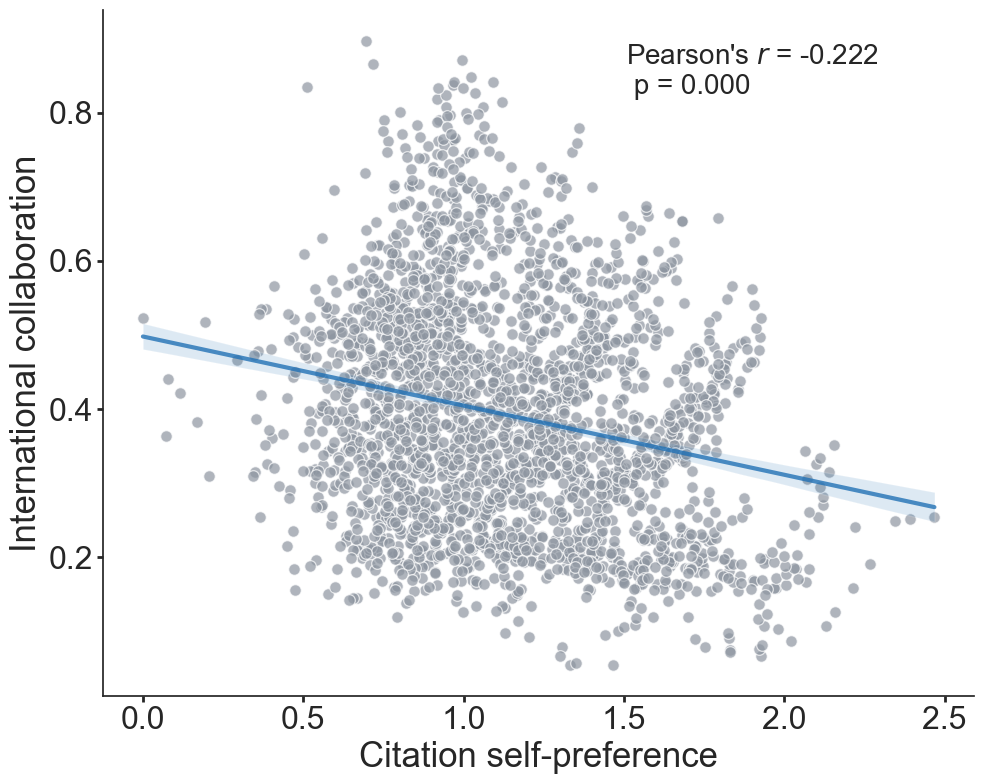

In [33]:
import copy

custom_params = {"axes.spines.right": False, "axes.spines.top": False,"axes.spines.left": True,"ytick.left":True,
                "axes.spines.bottom": True,"xtick.bottom":True,}
sns.set_theme(style='ticks', rc=custom_params)

filename_suffix='noselfauthor_bootstrap'

dfself_vars = pd.read_csv('RegressionSelfCitation/bootstrap_noselfauthor_R_disruption_03172026.csv')

fig, ax = plt.subplots(figsize=(10, 8))

colours=['#8D95A0','#2171b5','#DA6437']

data=copy.deepcopy(dfself_vars)

# for i in ['FracInternationalAuthors','logzscore',]:
#     data[i]=(data[i]-data[i].mean())/data[i].std()
    
sns.regplot(data=data, y='FracInternationalAuthors',x='logzscore',
               scatter_kws={'color': colours[0], 's':70, 'alpha':0.7,
                            'edgecolor': 'w', 'linewidths': 0.9 },  # grey dots
    line_kws={'color': colours[1], 'lw':3, 'alpha':0.8,}, 
            #x_bins=20 
           )

from scipy.stats import pearsonr

# Compute correlation
r, p = pearsonr(data['logzscore'], data['FracInternationalAuthors'])


ax.text(
    0.6, 0.95,  # x, y position in axis coordinates
    f"Pearson's $r$ = {r:.3f} \n p = {p:.3f}",
    transform=ax.transAxes,
    fontsize=20,
    ha='left',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.)
)

ax.set_ylabel('International collaboration', fontsize=25)
ax.set_xlabel('Citation self-preference', fontsize=25)
ax.tick_params(labelsize=23, direction='out', length=4, width=2) 


plt.tight_layout()
plt.savefig(f"FigureSelfCitation/NewData/SI_collabVSzscore_{filename_suffix}.pdf", bbox_inches='tight')

In [34]:
print('----- \n Overall correlation between collaboration and zscore:')
dfself_vars['FracInternationalAuthors'].corr(dfself_vars['logzscore'])

----- 
 Overall correlation between collaboration and zscore:


-0.2218518029094204

# Figure S6: Pearson’s correlation coefficient 𝑟 between international collaboration and citation self-preference for each year from 1990 to 2019. 

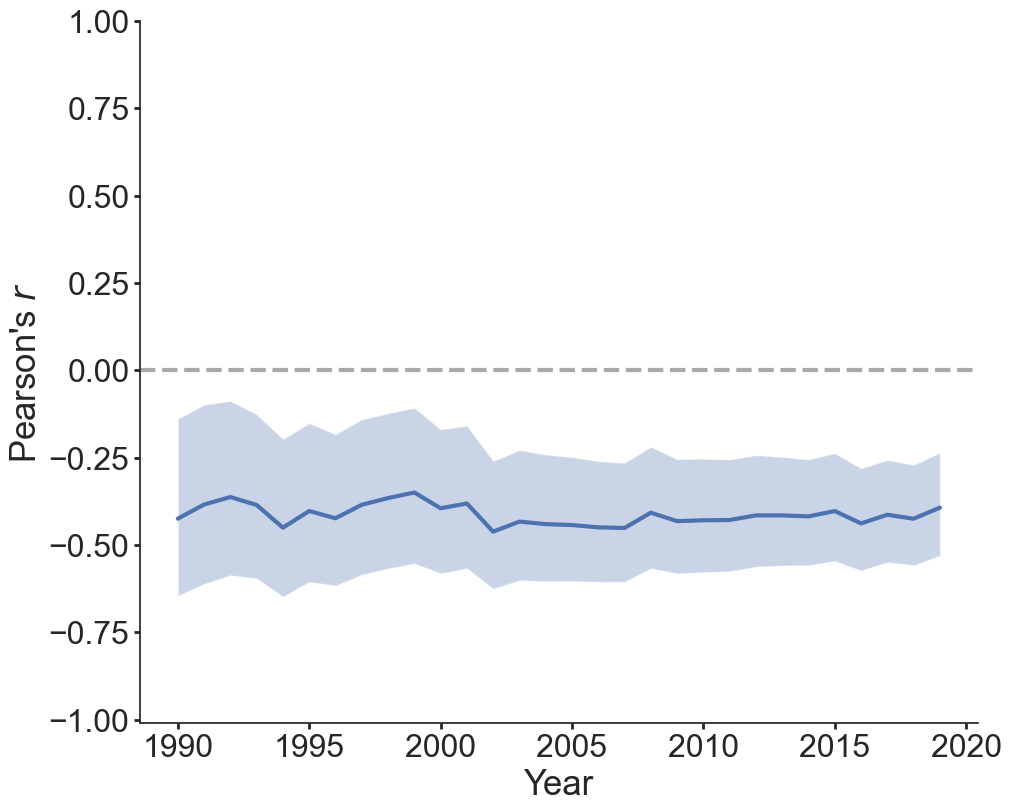

In [35]:
from scipy.stats import pearsonr

def corr_plot(subax, income_level,subtitle):
    df_clean = dfself_vars[['Year', 'FracInternationalAuthors', 'zscore', 'income_group']].dropna()
    if income_level!=None:
        df_clean = df_clean[df_clean['income_group']==income_level]
    
    def compute_correlation_ci(group, alpha=0.05):
        """Compute correlation and confidence interval"""
        x = group['FracInternationalAuthors']
        y = group['zscore']
        
        if len(group) < 3: 
            return pd.Series({
                'Correlation': np.nan,
                'CI_lower': np.nan,
                'CI_upper': np.nan,
                'n_obs': len(group)
            })
            
         # Compute correlation and p-value
        corr_coef, p_value = pearsonr(x, y)
        n = len(group)
        
        # Fisher transformation for confidence interval
        z = np.arctanh(corr_coef)  # Fisher z-transformation
        se = 1 / np.sqrt(n - 3)    # Standard error
        
        # Critical value for confidence interval
        from scipy.stats import norm
        z_critical = norm.ppf(1 - alpha/2)
        
        # Confidence interval in z-space
        z_lower = z - z_critical * se
        z_upper = z + z_critical * se
        
        # Transform back to correlation space
        ci_lower = np.tanh(z_lower)
        ci_upper = np.tanh(z_upper)
        
        return pd.Series({
            'Correlation': corr_coef,
            'CI_lower': ci_lower,
            'CI_upper': ci_upper,
            'p_value': p_value,
            'n_obs': n
        })
    
    correlations = (
        df_clean.groupby('Year')
        .apply(compute_correlation_ci)
        .reset_index()
    )
    
    ax = sns.lineplot(ax=subax, data=correlations, x='Year', y='Correlation', marker='',markersize=10, lw=3)
    
    subax.fill_between(correlations['Year'], 
                      correlations['CI_lower'], 
                      correlations['CI_upper'], 
                      alpha=0.3, 
                      label='95% CI')
    
    subax.axhline(0, color='darkgrey', linestyle='--',lw=3, alpha=1)
    
    subax.set_ylabel(f"Pearson's $r$", fontsize=25)
    subax.set_xlabel('Year', fontsize=25)
    subax.set_ylim([-1.01, 1])
    subax.tick_params(labelsize=23, direction='out', length=4, width=2) 
    
    
    return correlations  


custom_params = {"axes.spines.bottom": True, "axes.spines.right": False, "axes.spines.top": False,
                 "axes.spines.left": True,"ytick.left":True, "xtick.bottom":True}
sns.set_theme(style='ticks', rc=custom_params)
    

layout = [
    [ "A"],  
]

fig, axes = plt.subplot_mosaic(layout, figsize=(10, 8), 
                                  gridspec_kw={'height_ratios': [1],  "hspace": 0.1, "wspace": 0.1},
                                 constrained_layout=True, )


correlations1  = corr_plot(axes['A'], None,'All')

plt.savefig(f"FigureSelfCitation/NewData/SI_collabVSzscore_overyears_{filename_suffix}.pdf", bbox_inches='tight')

# Figure S4: Correlation between number of publications and citation self-preference(log z-score of AUC across country-years (1990-2019). 

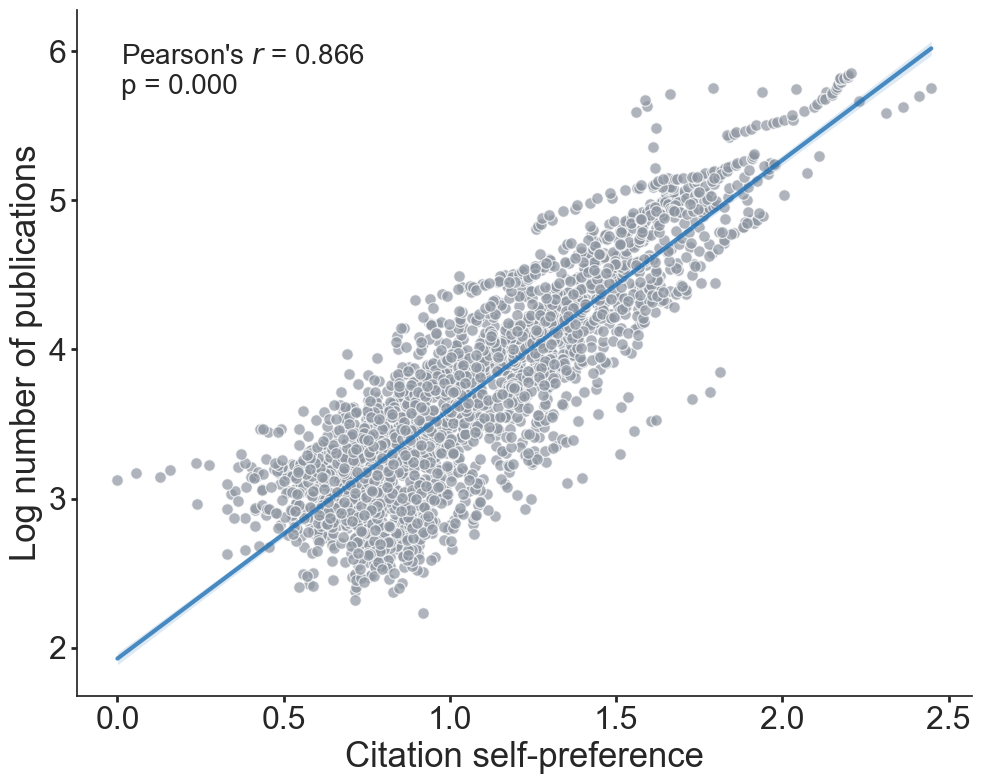

In [20]:
fig, ax = plt.subplots(figsize=(10, 8))

colours=['#8D95A0','#2171b5','#DA6437']

sns.regplot(data=dfself_vars, y='logNumPub',x='logzscore',
               scatter_kws={'color': colours[0], 's':70, 'alpha':0.7,
                            'edgecolor': 'w', 'linewidths': 0.9 },  # grey dots
    line_kws={'color': colours[1], 'lw':3,'alpha':0.8,}, 
            #x_bins=20 
           )

from scipy.stats import pearsonr

# Compute correlation
r, p = pearsonr(dfself_vars['logzscore'], dfself_vars['logNumPub'])


ax.text(
    0.05, 0.95,  # x, y position in axis coordinates
    f"Pearson's $r$ = {r:.3f} \np = {p:.3f}",
    transform=ax.transAxes,
    fontsize=20,
    ha='left',
    va='top',
    bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", lw=0.)
)

ax.set_ylabel('Log number of publications', fontsize=25)
ax.set_xlabel('Citation self-preference', fontsize=25)
ax.tick_params(labelsize=23, direction='out', length=4, width=2) 


plt.tight_layout()
plt.savefig(f"FigureSelfCitation/NewData/SI_numpubVSzscore_{filename_suffix}.pdf", bbox_inches='tight')

# Table S2: Regression estimates of citation self-preference on the number of publications.

In [36]:
import statsmodels.formula.api as smf
from stargazer.stargazer import Stargazer
from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
dfself_vars[['logNumPub', 'logzscore']] = scaler.fit_transform(dfself_vars[['logNumPub', 'logzscore']])


model1 = smf.ols('logNumPub ~ logzscore ', data=dfself_vars).fit()

model2 = smf.ols('logNumPub ~ logzscore + C(Year) ', data=dfself_vars).fit()
model3 = smf.ols('logNumPub ~ logzscore +C(Country)+ C(Year) ', data=dfself_vars).fit( cov_type='cluster',
    cov_kwds={'groups': dfself_vars['Country']})

stargazer = Stargazer([model1, model2, model3])
stargazer.covariate_order(['logzscore'])  # keep only logzscore

# Output LaTeX code
print(stargazer.render_latex())


\begin{table}[!htbp] \centering
\begin{tabular}{@{\extracolsep{5pt}}lccc}
\\[-1.8ex]\hline
\hline \\[-1.8ex]
& \multicolumn{3}{c}{\textit{Dependent variable: logNumPub}} \
\cr \cline{2-4}
\\[-1.8ex] & (1) & (2) & (3) \\
\hline \\[-1.8ex]
 logzscore & 0.868$^{***}$ & 0.901$^{***}$ & 0.389$^{***}$ \\
& (0.010) & (0.010) & (0.039) \\
\hline \\[-1.8ex]
 Observations & 2501 & 2501 & 2501 \\
 $R^2$ & 0.753 & 0.772 & 0.977 \\
 Adjusted $R^2$ & 0.752 & 0.769 & 0.976 \\
 Residual Std. Error & 0.498 (df=2499) & 0.481 (df=2470) & 0.156 (df=2337) \\
 F Statistic & 7601.008$^{***}$ (df=1; 2499) & 278.002$^{***}$ (df=30; 2470) & 814.734$^{***}$ (df=163; 2337) \\
\hline
\hline \\[-1.8ex]
\textit{Note:} & \multicolumn{3}{r}{$^{*}$p$<$0.1; $^{**}$p$<$0.05; $^{***}$p$<$0.01} \\
\end{tabular}
\end{table}
